**I. CLEAN DATA**

1. import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WalmartDatabase/features.csv")

# check kích thước
print("Kích thước dữ liệu:", df.shape)
df


Kích thước dữ liệu: (8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import pandas as pd

df1 = pd.read_csv("WalmartDatabase/train.csv")
print("Kích thước dữ liệu:", df1.shape)
df1


Kích thước dữ liệu: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2/5/2010,24924.50,False
1,1,1,2/12/2010,46039.49,True
2,1,1,2/19/2010,41595.55,False
3,1,1,2/26/2010,19403.54,False
4,1,1,3/5/2010,21827.90,False
...,...,...,...,...,...
421565,45,98,9/28/2012,508.37,False
421566,45,98,10/5/2012,628.10,False
421567,45,98,10/12/2012,1061.02,False
421568,45,98,10/19/2012,760.01,False


2. check thông tin

In [4]:
print("\nThông tin dữ liệu feature:\n")
df.info()

print("\nThống kê mô tả:\n")
print(df.describe())



Thông tin dữ liệu feature:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB

Thống kê mô tả:

             Store  Temperature   Fuel_Price      MarkDown1      MarkDown2  \
count  8190.000000  8190.000000  8190.000000    4032.000000    2921.000000   
mean     23.000

In [5]:
print("\nThông tin dữ liệu train:\n")
df1.info()

print("\nThống kê mô tả:\n")
print(df1.describe())


Thông tin dữ liệu train:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Thống kê mô tả:

               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000


3.1. tìm missing value (feature.csv)

In [6]:
# ktra gtri null từng cột
missing = df.isnull().sum()
print("\nSố lượng giá trị bị thiếu:\n", missing)

# nếu cột bị thiếu nhiều, xét tỷ lệ %
print("\nTỷ lệ thiếu (%):\n", (missing / len(df)) * 100)


Số lượng giá trị bị thiếu:
 Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Tỷ lệ thiếu (%):
 Store            0.000000
Date             0.000000
Temperature      0.000000
Fuel_Price       0.000000
MarkDown1       50.769231
MarkDown2       64.334554
MarkDown3       55.885226
MarkDown4       57.704518
MarkDown5       50.549451
CPI              7.142857
Unemployment     7.142857
IsHoliday        0.000000
dtype: float64


In [7]:
# Điền giá trị mean vào những giá trị bị miss
df['CPI'] = df['CPI'].fillna(df['CPI'].mean())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].mean())
df['MarkDown1'] = df['MarkDown1'].fillna(df['MarkDown1'].mean())
df['MarkDown2'] = df['MarkDown2'].fillna(df['MarkDown2'].mean())
df['MarkDown3'] = df['MarkDown3'].fillna(df['MarkDown3'].mean())
df['MarkDown4'] = df['MarkDown4'].fillna(df['MarkDown4'].mean())
df['MarkDown5'] = df['MarkDown5'].fillna(df['MarkDown5'].mean())

# Check lại
missing_after_imputation = df.isnull().sum()
print("\nSố lượng giá trị bị thiếu sau khi điền:\n", missing_after_imputation)


Số lượng giá trị bị thiếu sau khi điền:
 Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


3.2. tìm missing value (train.csv)

In [8]:
# ktra gtri null từng cột
missing = df1.isnull().sum()
print("\nSố lượng giá trị bị thiếu:\n", missing)

# nếu cột bị thiếu nhiều, xét tỷ lệ %
print("\nTỷ lệ thiếu (%):\n", (missing / len(df1)) * 100)


Số lượng giá trị bị thiếu:
 Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Tỷ lệ thiếu (%):
 Store           0.0
Dept            0.0
Date            0.0
Weekly_Sales    0.0
IsHoliday       0.0
dtype: float64


4.1. Tìm dữ liệu bị trùng lặp (feature.csv)

In [9]:
dupes = df.duplicated().sum()
print(f"\nSố hàng bị trùng lặp: {dupes}")


Số hàng bị trùng lặp: 0


4.2. Tìm dữ liệu bị trùng lặp (train.csv)

In [10]:
dupes = df1.duplicated().sum()
print(f"\nSố hàng bị trùng lặp: {dupes}")


Số hàng bị trùng lặp: 0


5.1. Tìm ra dữ liệu bất thường / không hợp lệ (feature.csv)

Các cột số: ['Store', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']

Các cột có giá trị âm (có thể không hợp lệ):
  - Temperature: 4 giá trị âm
  - MarkDown1: 4 giá trị âm
  - MarkDown2: 25 giá trị âm
  - MarkDown3: 13 giá trị âm
  - MarkDown5: 2 giá trị âm

Thống kê outlier theo cột:
             Cột  Số lượng outlier  Tỷ lệ (%)
0         Store                 0       0.00
1   Temperature                 7       0.09
2    Fuel_Price                 0       0.00
3     MarkDown1              1803      22.01
4     MarkDown2               376       4.59
5     MarkDown3               108       1.32
6     MarkDown4               484       5.91
7     MarkDown5               950      11.60
8           CPI                 0       0.00
9  Unemployment               559       6.83


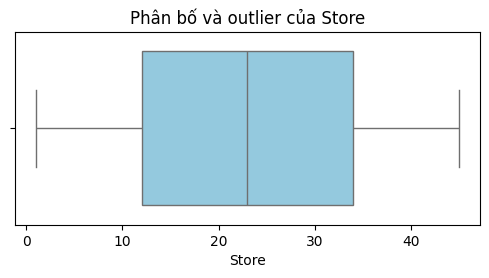

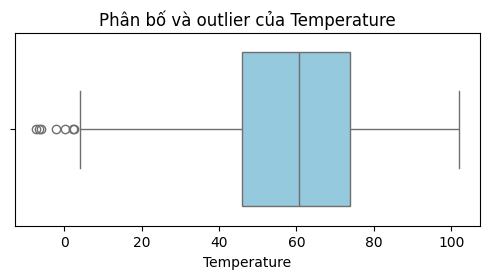

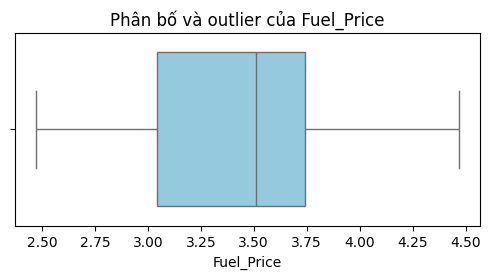

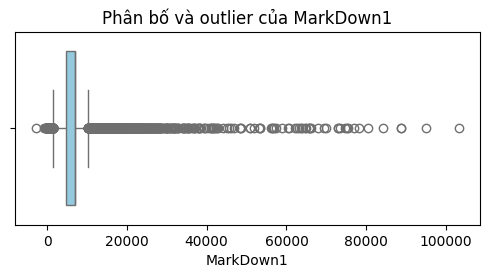

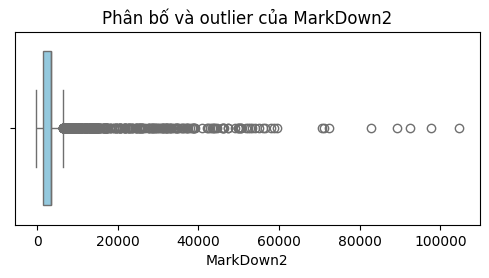

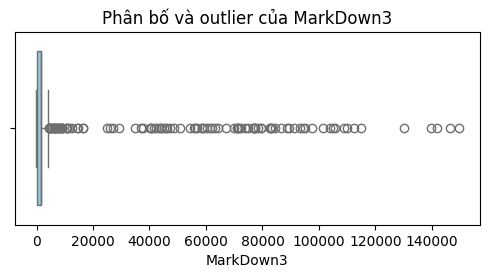

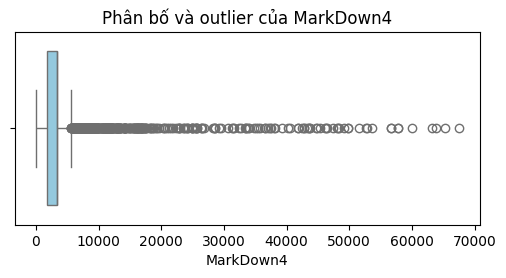

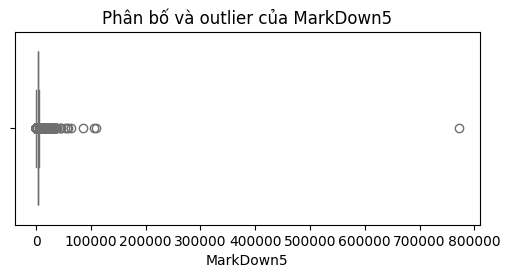

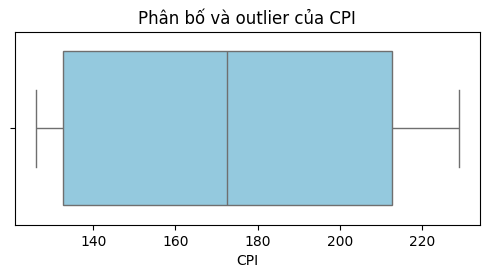

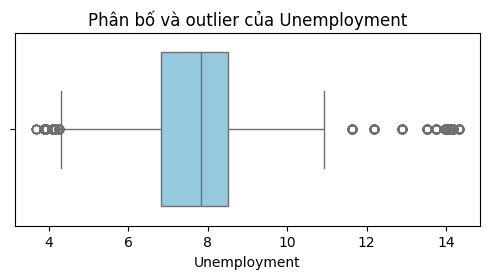

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 5.1 Xác định các cột số
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Các cột số:", numeric_cols)

# 5.2 Kiểm tra giá trị âm
negative_values = {}
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        negative_values[col] = neg_count

if len(negative_values) > 0:
    print("\nCác cột có giá trị âm (có thể không hợp lệ):")
    for col, count in negative_values.items():
        print(f"  - {col}: {count} giá trị âm")
else:
    print("\nKhông có giá trị âm bất thường nào trong dữ liệu.")

# 5.3 Phát hiện outlier = IQR
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100

    outlier_summary.append({
        'Cột': col,
        'Số lượng outlier': len(outliers),
        'Tỷ lệ (%)': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\nThống kê outlier theo cột:\n", outlier_df)

# 5.4 Vẽ boxplot
for col in numeric_cols:
    plt.figure(figsize=(6, 2.5))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Phân bố và outlier của {col}")
    plt.show()


5.2.Tìm ra dữ liệu bất thường / không hợp lệ (train.csv)

Các cột số: ['Store', 'Dept', 'Weekly_Sales']

Các cột có giá trị âm (có thể không hợp lệ):
  - Weekly_Sales: 1285 giá trị âm

Thống kê outlier theo cột:
             Cột  Số lượng outlier  Tỷ lệ (%)
0         Store                 0       6.83
1          Dept                 0       6.83
2  Weekly_Sales             35521       6.83


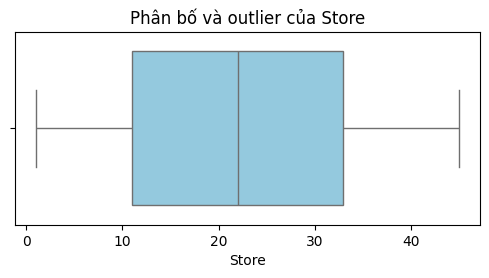

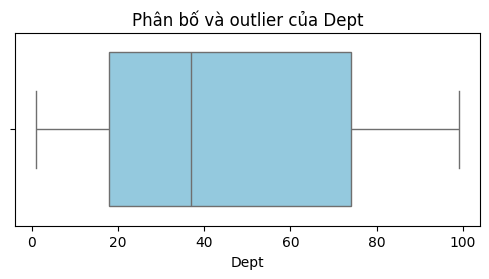

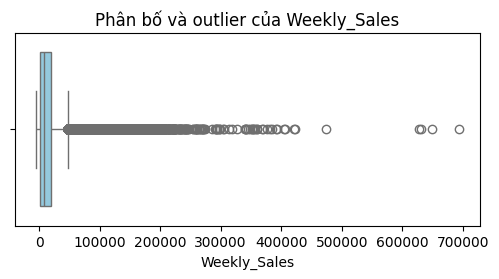

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 5.1 Xác định các cột số
numeric_cols1 = df1.select_dtypes(include=[np.number]).columns.tolist()
print("Các cột số:", numeric_cols1)

# 5.2 Kiểm tra giá trị âm
negative_values1 = {}
for col in numeric_cols1:
    neg_count1 = (df1[col] < 0).sum()
    if neg_count1 > 0:
        negative_values1[col] = neg_count1

if len(negative_values1) > 0:
    print("\nCác cột có giá trị âm (có thể không hợp lệ):")
    for col, count in negative_values1.items():
        print(f"  - {col}: {count} giá trị âm")
elif not numeric_cols1:
    print("\nKhông có cột số nào để kiểm tra giá trị âm.")
else:
    print("\nKhông có giá trị âm bất thường nào trong dữ liệu.")

# 5.3 Phát hiện outlier = IQR
outlier_summary1 = []

for col in numeric_cols1:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers1 = df1[(df1[col] < lower_bound) | (df1[col] > upper_bound)]
    outlier_pct1 = (len(outliers1) / len(df1)) * 100

    outlier_summary1.append({
        'Cột': col,
        'Số lượng outlier': len(outliers1),
        'Tỷ lệ (%)': round(outlier_pct, 2)
    })

outlier_df1 = pd.DataFrame(outlier_summary1)
print("\nThống kê outlier theo cột:\n", outlier_df1)

# 5.4 Vẽ boxplot
for col in numeric_cols1:
    plt.figure(figsize=(6, 2.5))
    sns.boxplot(x=df1[col], color='skyblue')
    plt.title(f"Phân bố và outlier của {col}")
    plt.show()

6.1. Thống kê mô tả dữ liệu (Descriptive Statistics) (feature.csv)


Thống kê mô tả dữ liệu số:

               count         mean          std       min          25%  \
Store         8190.0    23.000000    12.987966     1.000    12.000000   
Temperature   8190.0    59.356198    18.678607    -7.290    45.902500   
Fuel_Price    8190.0     3.405992     0.431337     2.472     3.041000   
MarkDown1     8190.0  7032.371786  6498.764307 -2781.450  4842.382500   
MarkDown2     8190.0  3384.176594  5250.998063  -265.760  1410.940000   
MarkDown3     8190.0  1760.100180  7489.128873  -179.260    54.017500   
MarkDown4     8190.0  3292.935886  4417.022169     0.220  1737.530000   
MarkDown5     8190.0  4132.216422  9202.128149  -185.170  2753.105000   
CPI           8190.0   172.460809    38.292649   126.064   132.653774   
Unemployment  8190.0     7.826821     1.808963     3.684     6.833000   

                      50%          75%            max       median   skewness  \
Store           23.000000    34.000000      45.000000    23.000000   0.000000   
Tempe

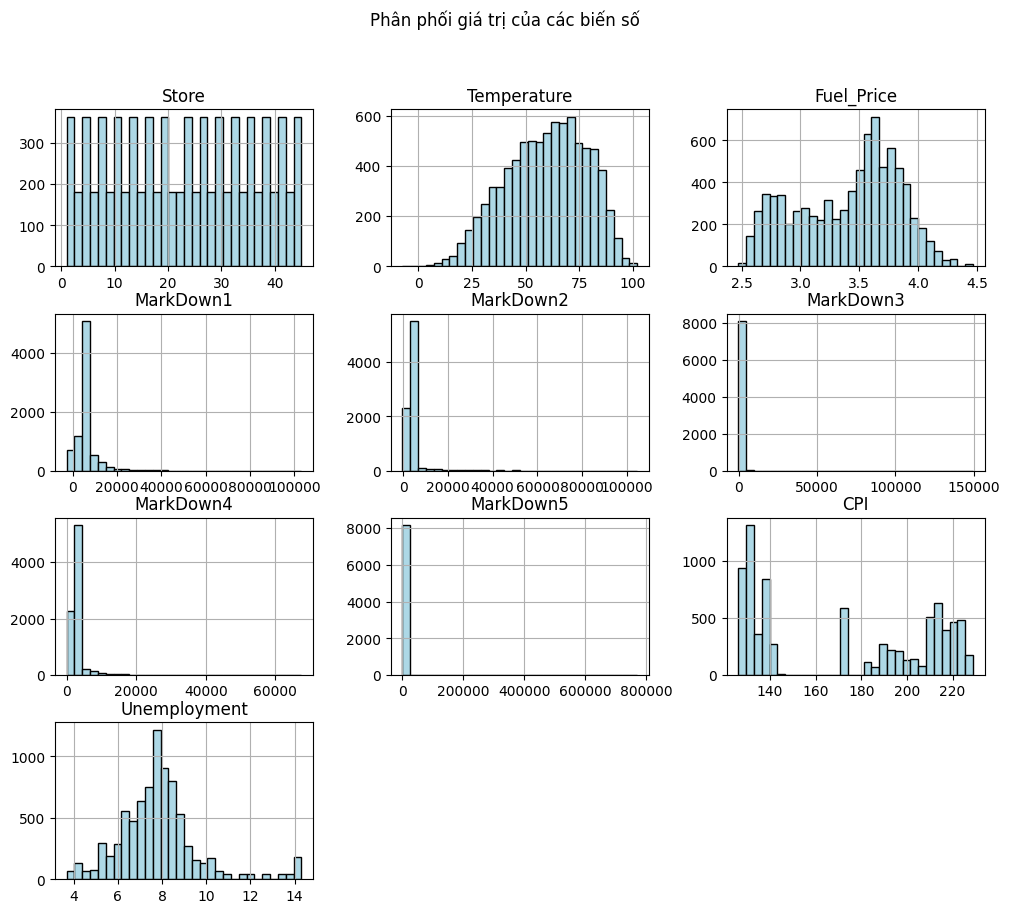

In [13]:
# Thống kê cơ bản
stats_summary = df[numeric_cols].describe().T
stats_summary["median"] = df[numeric_cols].median()
stats_summary["skewness"] = df[numeric_cols].skew()
stats_summary["kurtosis"] = df[numeric_cols].kurtosis()

print("\nThống kê mô tả dữ liệu số:\n")
print(stats_summary)

# Nhận diện cột phân phối lệch mạnh
skewed_cols = stats_summary[abs(stats_summary["skewness"]) > 1].index.tolist()
if skewed_cols:
    print("\nCác cột có phân phối lệch mạnh (|skewness| > 1):")
    print(skewed_cols)
else:
    print("\nKhông có cột nào bị lệch phân phối nghiêm trọng.")

# Vẽ biểu đồ phân phối histogram
df[numeric_cols].hist(figsize=(12, 10), bins=30, color='lightblue', edgecolor='black')
plt.suptitle("Phân phối giá trị của các biến số")
plt.show()


6.2.Thống kê mô tả dữ liệu (Descriptive Statistics) (train.csv)


Thống kê mô tả dữ liệu số:

                 count          mean           std      min      25%      50%  \
Store         421570.0     22.200546     12.785297     1.00    11.00    22.00   
Dept          421570.0     44.260317     30.492054     1.00    18.00    37.00   
Weekly_Sales  421570.0  15981.258123  22711.183519 -4988.94  2079.65  7612.03   

                     75%        max   median  skewness   kurtosis  
Store            33.0000      45.00    22.00  0.077763  -1.146503  
Dept             74.0000      99.00    37.00  0.358223  -1.215571  
Weekly_Sales  20205.8525  693099.36  7612.03  3.262008  21.491290  

Các cột có phân phối lệch mạnh (|skewness| > 1):
['Weekly_Sales']


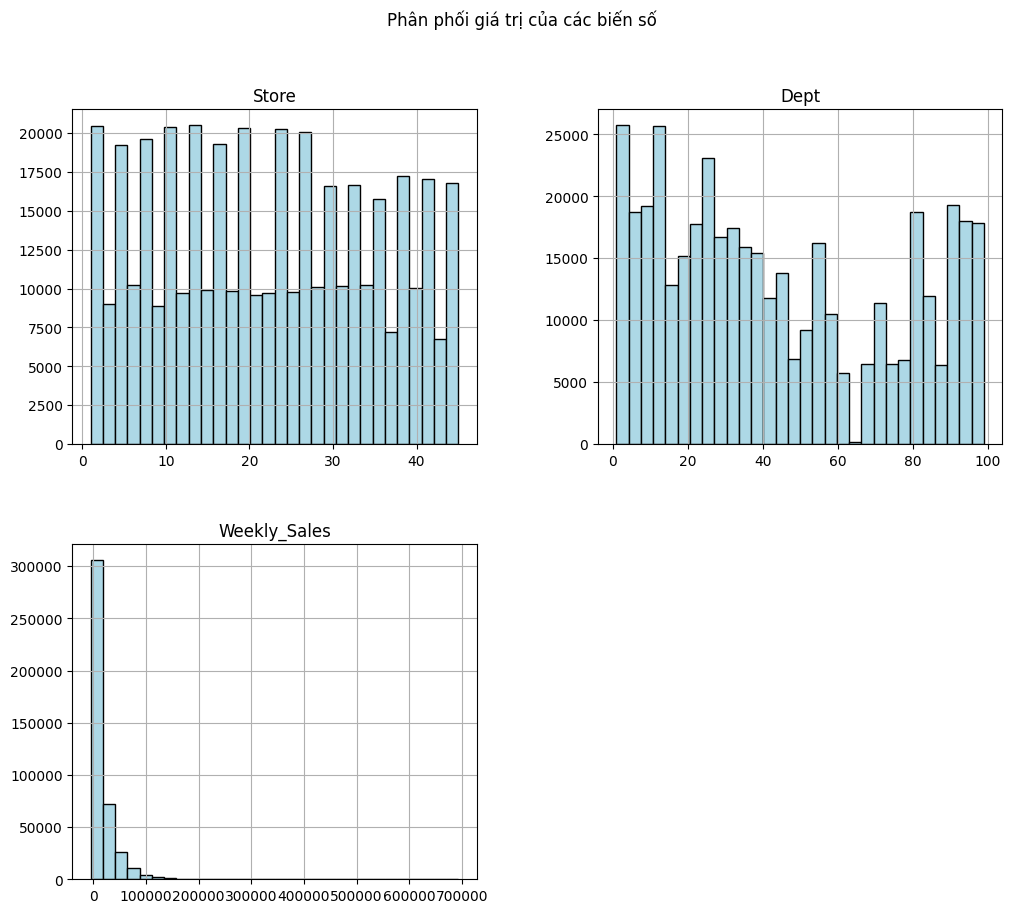

In [14]:
# Thống kê cơ bản
stats_summary1 = df1[numeric_cols1].describe().T
stats_summary1["median"] = df1[numeric_cols1].median()
stats_summary1["skewness"] = df1[numeric_cols1].skew()
stats_summary1["kurtosis"] = df1[numeric_cols1].kurtosis()

print("\nThống kê mô tả dữ liệu số:\n")
print(stats_summary1)

# Nhận diện cột phân phối lệch mạnh
skewed_cols1 = stats_summary1[abs(stats_summary1["skewness"]) > 1].index.tolist()
if skewed_cols1:
    print("\nCác cột có phân phối lệch mạnh (|skewness| > 1):")
    print(skewed_cols1)
else:
    print("\nKhông có cột nào bị lệch phân phối nghiêm trọng.")

# Vẽ biểu đồ phân phối histogram
df1[numeric_cols1].hist(figsize=(12, 10), bins=30, color='lightblue', edgecolor='black')
plt.suptitle("Phân phối giá trị của các biến số")
plt.show()

7.1. Xử lý dữ liệu bất thường đã thấy ở phần 5 và 6 (feature.csv)

In [15]:
import numpy as np

# Xử lý giá trị âm (thay = NaN)
negative_cols = []
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        df.loc[df[col] < 0, col] = np.nan
        negative_cols.append(col)
if negative_cols:
    print("Đã thay giá trị âm thành NaN ở các cột:", negative_cols)
else:
    print("Không có giá trị âm cần xử lý.")

# Xử lý outlier bằng phương pháp IQR (Winsorization – cắt giá trị vượt ngưỡng)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("Đã cắt (clip) giá trị outlier ngoài phạm vi IQR cho tất cả cột số.")

# Biến đổi log cho các cột có skewness cao
skewed_cols = stats_summary[abs(stats_summary["skewness"]) > 1].index.tolist()
if skewed_cols:
    for col in skewed_cols:
        # chỉ log-transform nếu toàn bộ giá trị >= 0
        if (df[col] >= 0).all():
            df[col] = np.log1p(df[col])
    print("Đã log-transform các cột có skewness cao:", skewed_cols)
else:
    print("Không có cột nào bị lệch mạnh cần log-transform.")

# Điền giá trị thiếu (median fill)
df.fillna(df.median(numeric_only=True), inplace=True)
print("Đã điền giá trị thiếu bằng median của từng cột.")

# Kiểm tra lại dữ liệu sau khi xử lý
print("\nKiểm tra lại thống kê sau xử lý:\n")
print(df[numeric_cols].describe().T)

# Lưu dữ liệu sạch ra file mới
df.to_csv("cleaned_features.csv", index=False)
print("\nDữ liệu sạch đã được lưu thành 'cleaned_features.csv'")


Đã thay giá trị âm thành NaN ở các cột: ['Temperature', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown5']
Đã cắt (clip) giá trị outlier ngoài phạm vi IQR cho tất cả cột số.
Đã log-transform các cột có skewness cao: ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Unemployment']
Đã điền giá trị thiếu bằng median của từng cột.

Kiểm tra lại thống kê sau xử lý:

               count         mean          std          min          25%  \
Store         8190.0    23.000000    12.987966     1.000000    12.000000   
Temperature   8190.0    59.389383    18.620902     3.955000    45.912500   
Fuel_Price    8190.0     3.405992     0.431337     2.472000     3.041000   
MarkDown1     8190.0  6220.340841  2520.539755  1580.161071  4853.332500   
MarkDown2     8190.0  2746.607068  1567.458050     0.000000  1560.760000   
MarkDown3     8190.0  1110.326670   903.048760     0.000000    55.495000   
MarkDown4     8190.0     7.483330     1.383026     0.198851     7.460794   
MarkDown5 

7.2. Xử lý dữ liệu bất thường đã thấy ở phần 5 và 6 (train.csv)

In [16]:
import numpy as np

# Xử lý giá trị âm (thay = NaN)
negative_cols1 = []
for col in numeric_cols1:
    neg_count1 = (df1[col] < 0).sum()
    if neg_count1 > 0:
        df1.loc[df1[col] < 0, col] = np.nan
        negative_cols1.append(col)
if negative_cols1:
    print("Đã thay giá trị âm thành NaN ở các cột:", negative_cols1)
else:
    print("Không có giá trị âm cần xử lý.")

# Xử lý outlier bằng phương pháp IQR (Winsorization – cắt giá trị vượt ngưỡng)
for col in numeric_cols1:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df1[col] = np.clip(df1[col], lower, upper)

print("Đã cắt (clip) giá trị outlier ngoài phạm vi IQR cho tất cả cột số.")

# Biến đổi log cho các cột có skewness cao
skewed_cols1 = stats_summary1[abs(stats_summary1["skewness"]) > 1].index.tolist()
if skewed_cols1:
    for col in skewed_cols1:
        # chỉ log-transform nếu toàn bộ giá trị >= 0
        if (df1[col] >= 0).all():
            df1[col] = np.log1p(df1[col])
    print("Đã log-transform các cột có skewness cao:", skewed_cols1)
else:
    print("Không có cột nào bị lệch mạnh cần log-transform.")

# Kiểm tra lại dữ liệu sau khi xử lý
print("\nKiểm tra lại thống kê sau xử lý:\n")
print(df1[numeric_cols1].describe().T)

# Lưu dữ liệu sạch ra file mới
df1.to_csv("cleaned_train.csv", index=False)
print("\nDữ liệu sạch đã được lưu thành 'cleaned_train.csv'")

Đã thay giá trị âm thành NaN ở các cột: ['Weekly_Sales']
Đã cắt (clip) giá trị outlier ngoài phạm vi IQR cho tất cả cột số.
Đã log-transform các cột có skewness cao: ['Weekly_Sales']

Kiểm tra lại thống kê sau xử lý:

                 count          mean           std  min      25%      50%  \
Store         421570.0     22.200546     12.785297  1.0    11.00    22.00   
Dept          421570.0     44.260317     30.492054  1.0    18.00    37.00   
Weekly_Sales  420285.0  13699.734648  14931.184769  0.0  2117.56  7659.09   

                   75%       max  
Store            33.00     45.00  
Dept             74.00     99.00  
Weekly_Sales  20268.38  47494.61  

Dữ liệu sạch đã được lưu thành 'cleaned_train.csv'


**II. VẼ BIỂU ĐỒ XU HƯỚNG **
1. feature.csv


In [17]:
# Xác định kiểu dữ liệu và cột quan trọng
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print("Các cột số:", numeric_cols)
print("Các cột phân loại:", cat_cols)


Các cột số: ['Store', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']
Các cột phân loại: ['Date', 'IsHoliday']


C:\Users\asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


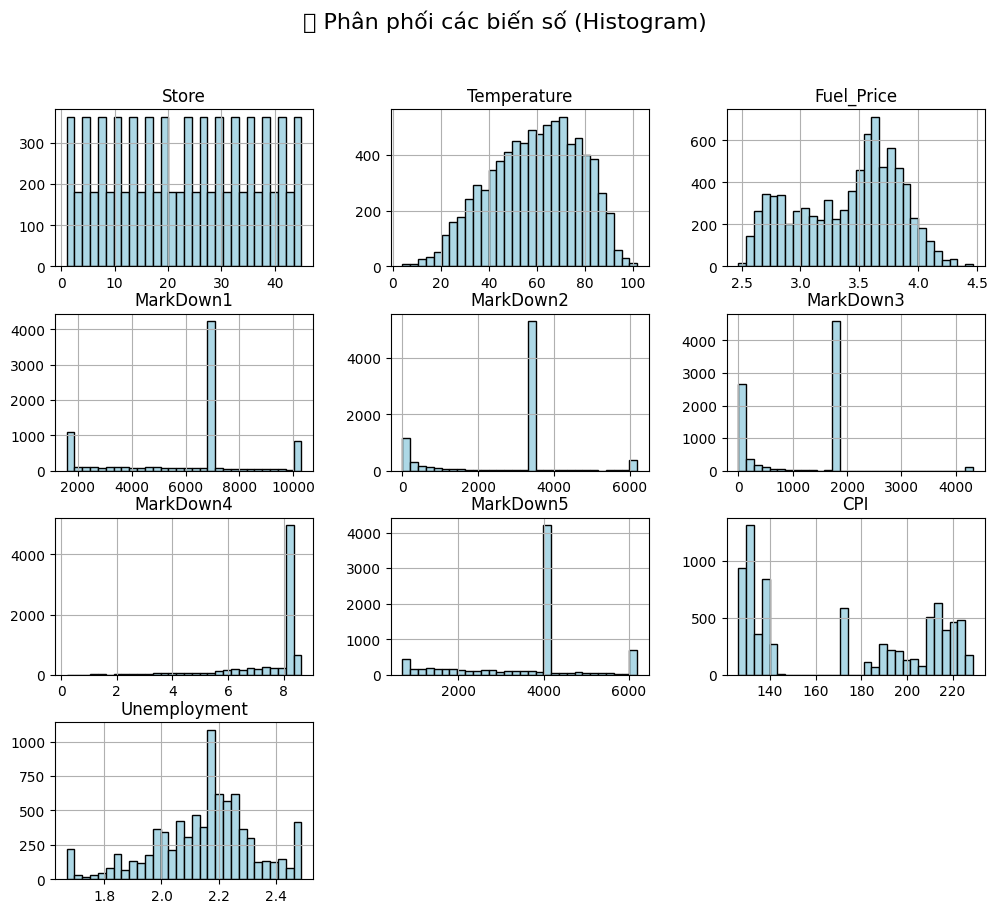

In [18]:
# 1. Biểu đồ phân phối giá trị (Histogram)
df[numeric_cols].hist(figsize=(12, 10), bins=30, color='lightblue', edgecolor='black')
plt.suptitle("📊 Phân phối các biến số (Histogram)", fontsize=16)
plt.show()


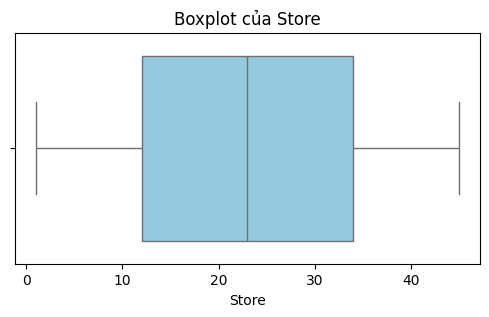

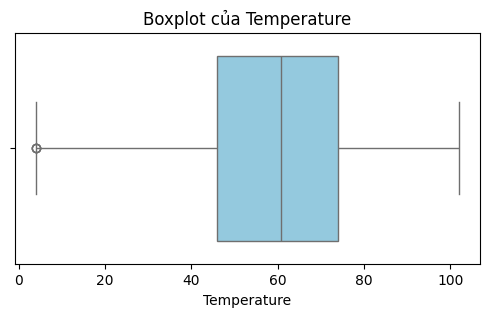

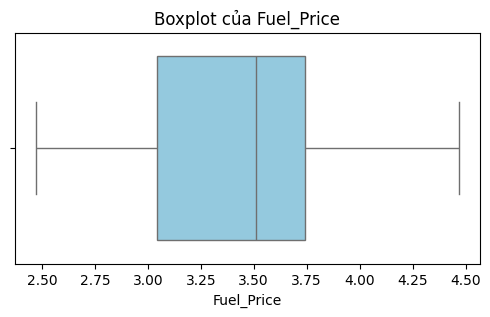

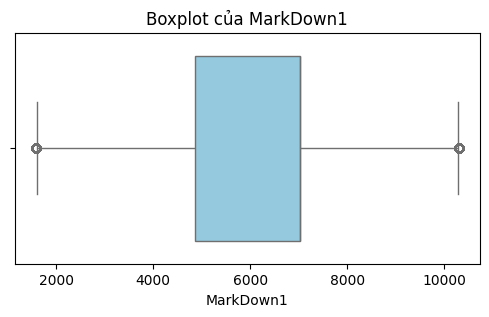

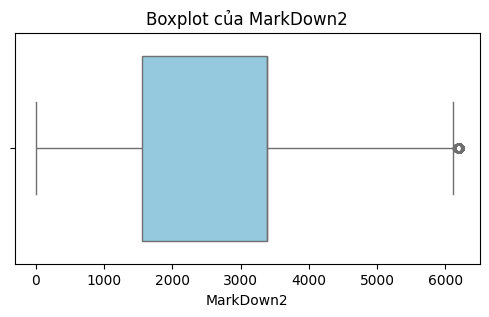

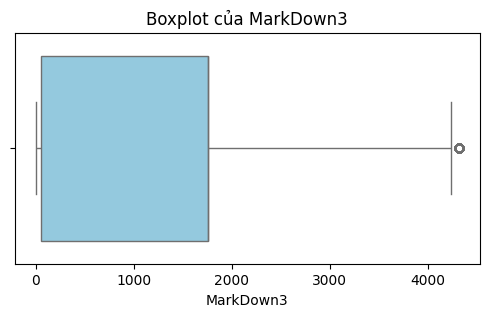

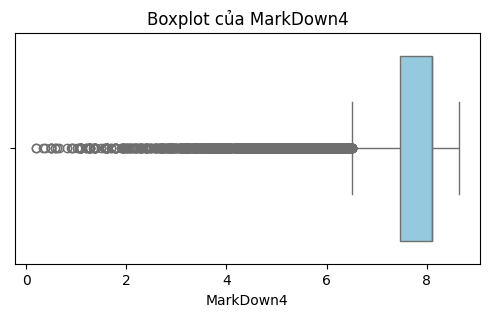

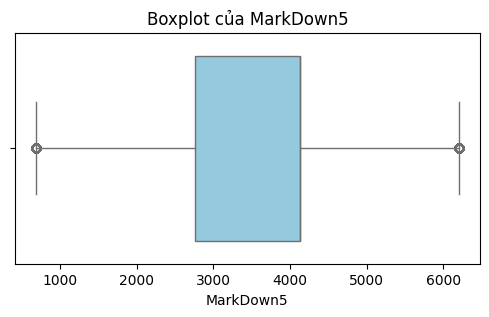

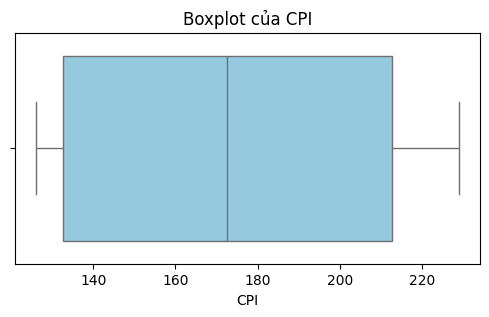

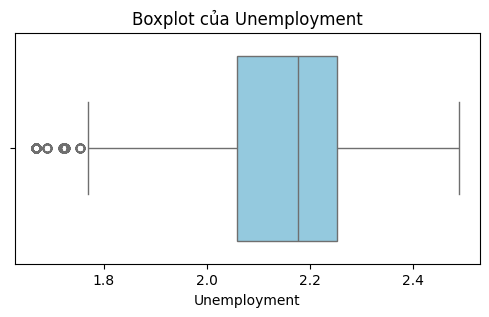

In [19]:
# 2. Boxplot (phát hiện outlier và so sánh biến)
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Boxplot của {col}")
    plt.show()

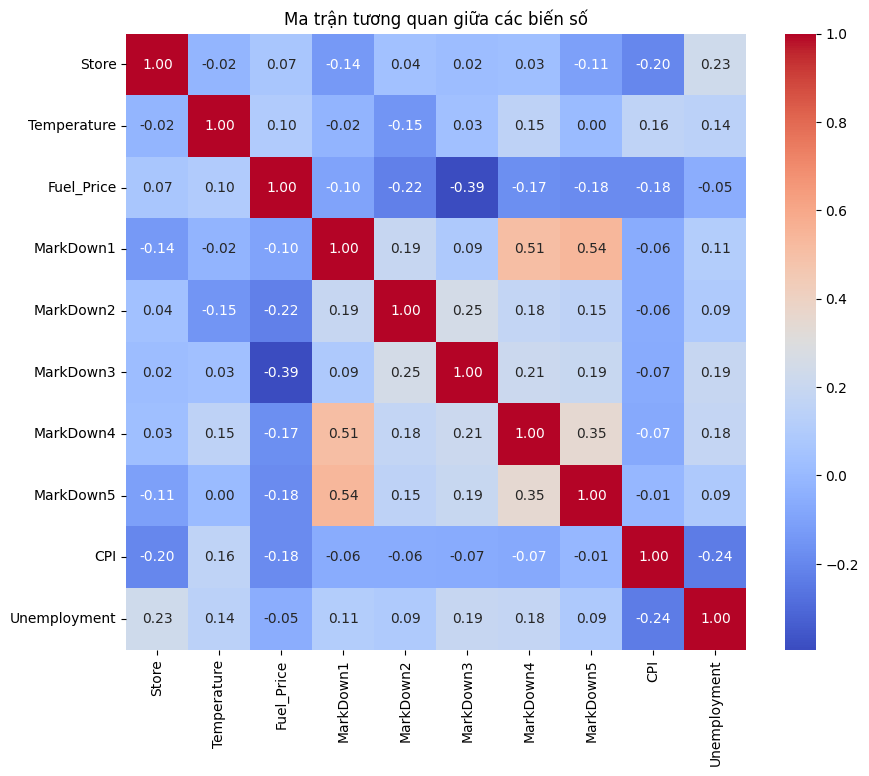

In [20]:
# 3. Heatmap tương quan (Correlation Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()


In [21]:
# 4. Xu hướng theo thời gian (nếu có cột date hoặc year, month)
# Nếu có cột thời gian
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

    # Ví dụ: xu hướng trung bình của 1 biến theo thời gian
    plt.figure(figsize=(10, 4))
    sns.lineplot(x='date', y=df[numeric_cols[0]], data=df)
    plt.title(f"Xu hướng của {numeric_cols[0]} theo thời gian")
    plt.xlabel("Thời gian")
    plt.ylabel(numeric_cols[0])
    plt.show()


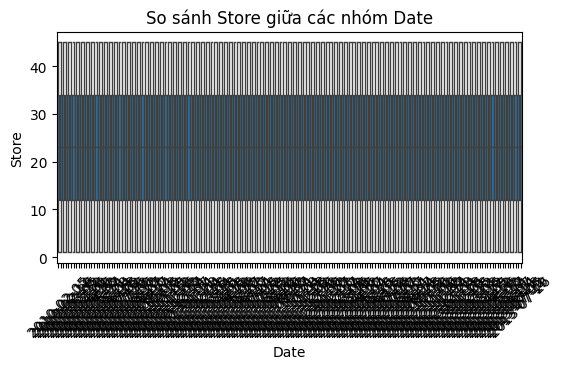

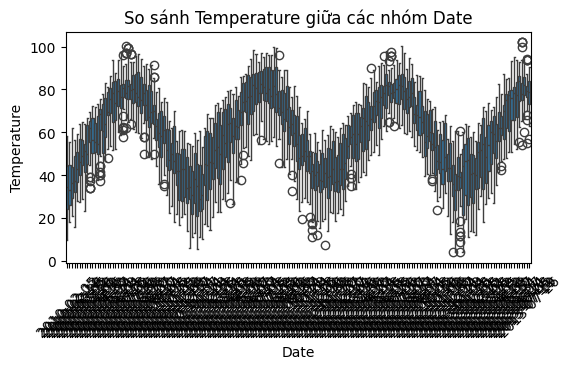

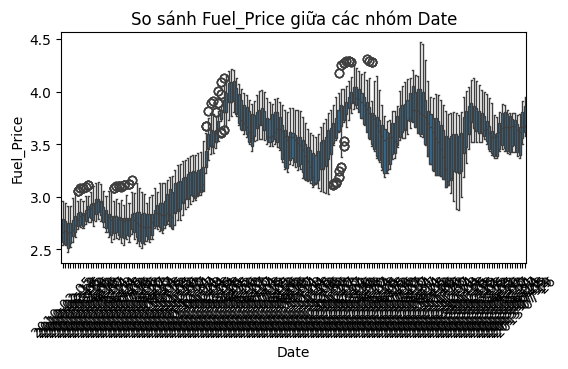

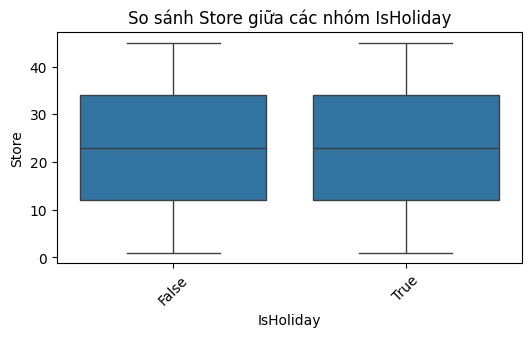

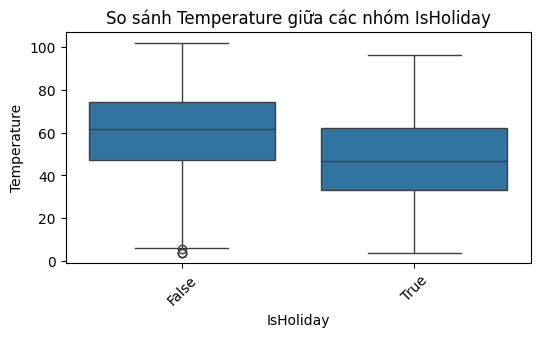

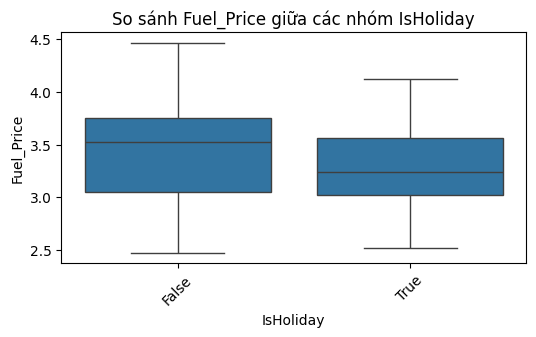

In [22]:
# 5. So sánh biến số với biến phân loại
for col in cat_cols[:3]:  # chỉ lấy vài cột phân loại đầu tiên
    for num in numeric_cols[:3]:
        plt.figure(figsize=(6, 3))
        sns.boxplot(x=col, y=num, data=df)
        plt.title(f"So sánh {num} giữa các nhóm {col}")
        plt.xticks(rotation=45)
        plt.show()


C:\Users\asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


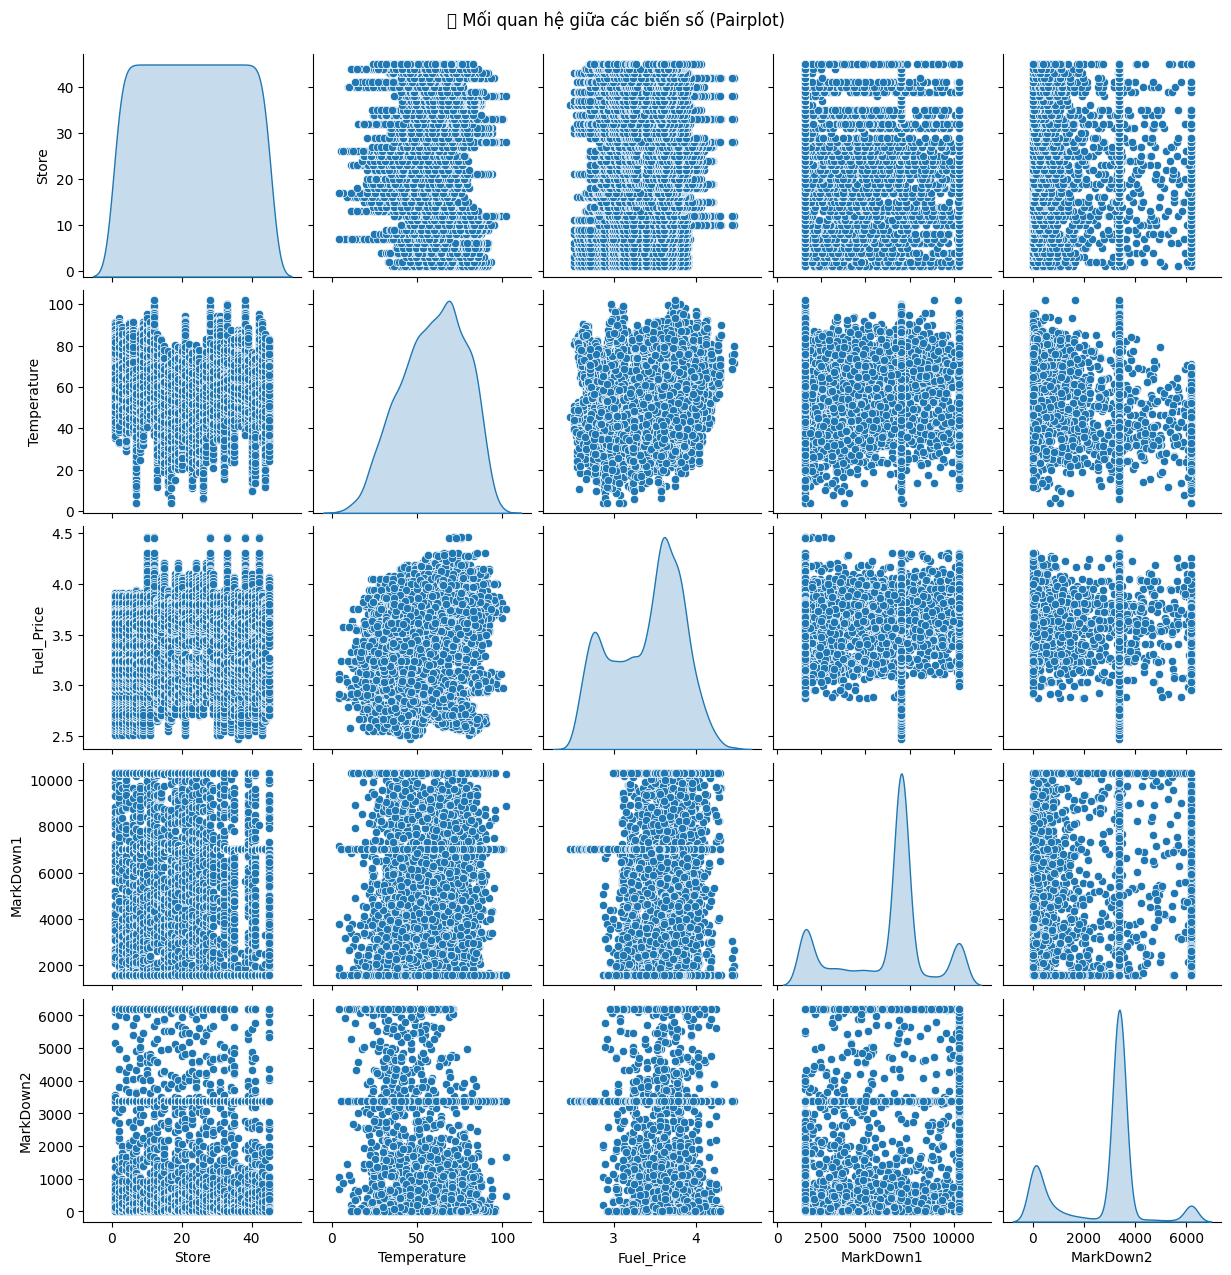

In [23]:
# 6. Pairplot (nhìn tổng thể mối quan hệ giữa các biến)
sns.pairplot(df[numeric_cols[:5]], diag_kind='kde')
plt.suptitle("🔍 Mối quan hệ giữa các biến số (Pairplot)", y=1.02)
plt.show()


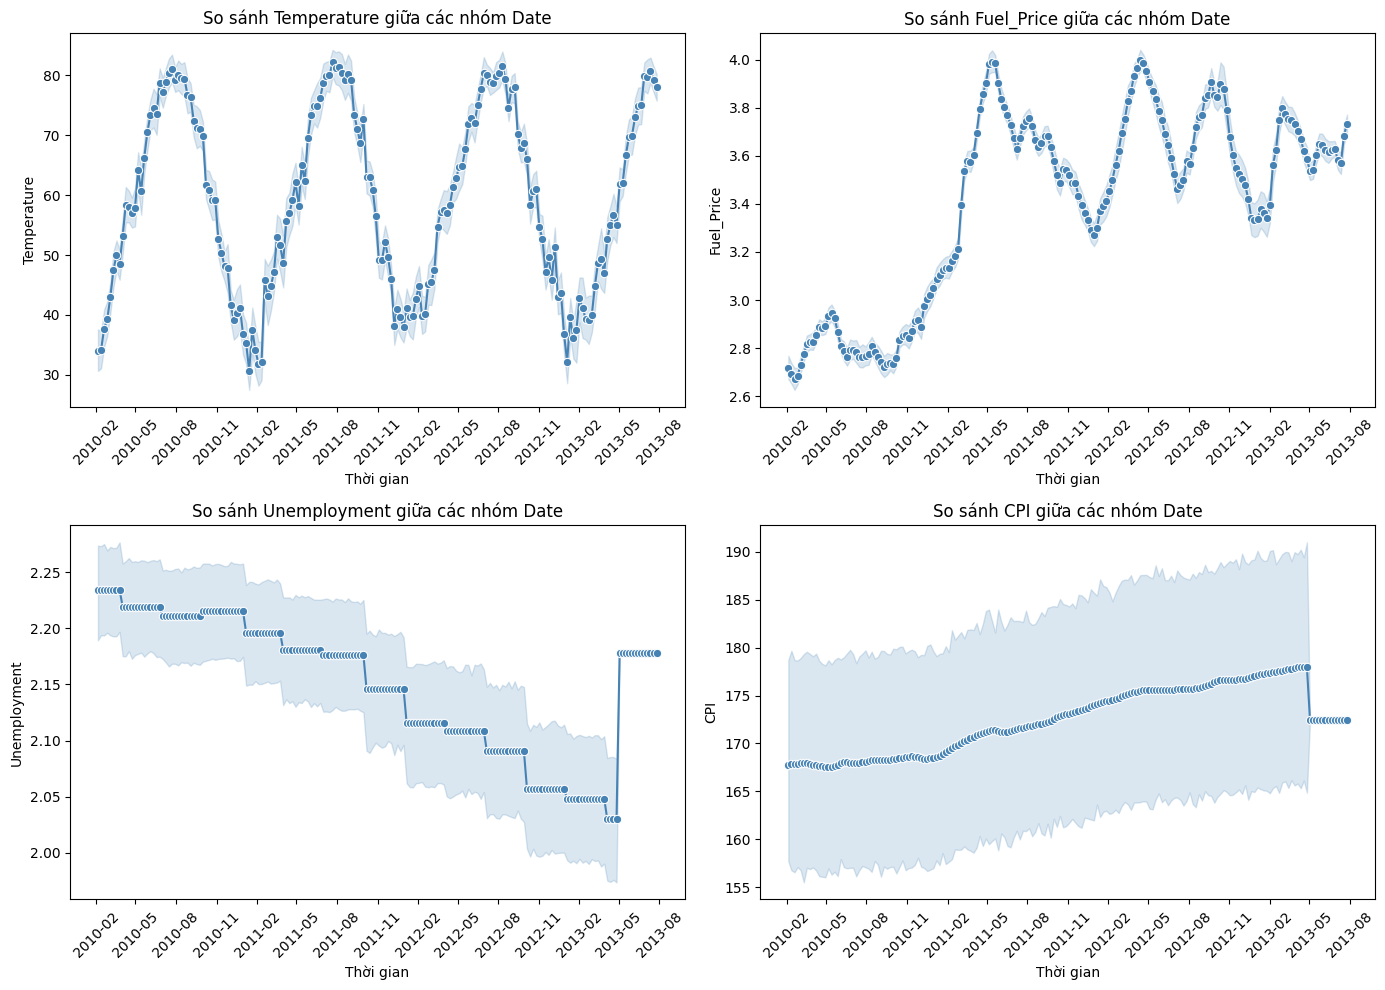

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd

try:
  df = pd.read_csv("cleaned_features.csv")
except FileNotFoundError:
  print ("Error")
  exit()

df['Date'] = pd.to_datetime(df['Date'])


features_to_plot = ['Temperature', 'Fuel_Price', 'Unemployment', 'CPI']

plt.figure(figsize=(14, 10))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)  # chia thành 2 hàng, 2 cột
    sns.lineplot(x='Date', y=col, data=df, marker='o', color='steelblue')
    plt.title(f"So sánh {col} giữa các nhóm Date")
    plt.xlabel("Thời gian")
    plt.ylabel(col)

    # Giảm nhãn ngày: chỉ hiển thị theo tháng và năm
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # hiển thị năm và tháng
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # hiển thị cách 3 tháng một lần
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

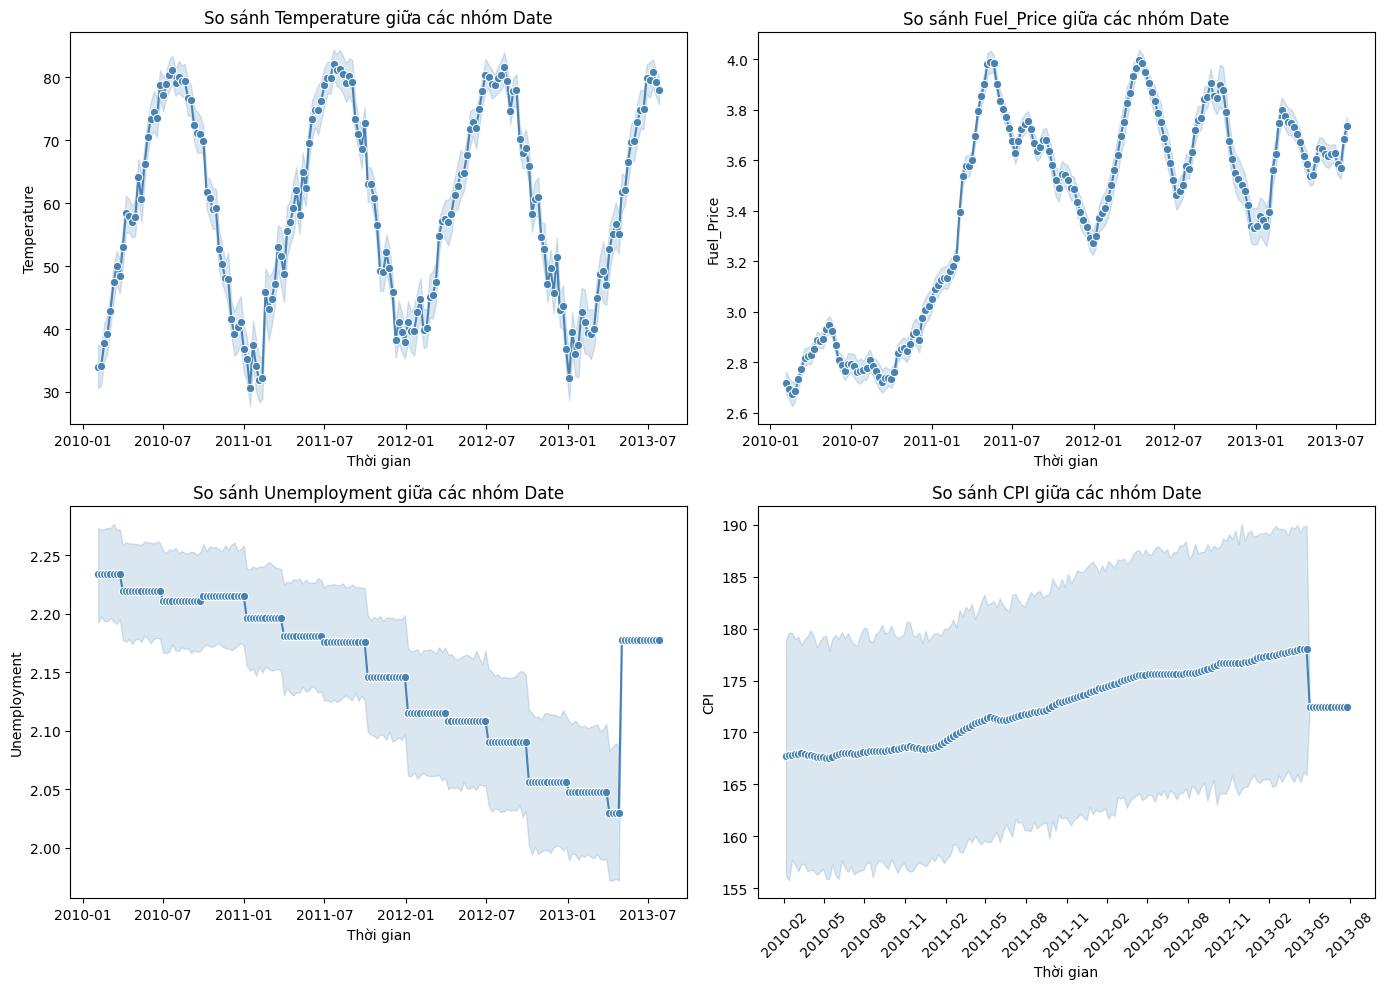

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd

try:
  df = pd.read_csv("cleaned_features.csv")
except FileNotFoundError:
  print ("Error")
  exit()

df['Date'] = pd.to_datetime(df['Date'])

features_to_plot = ['Temperature', 'Fuel_Price', 'Unemployment', 'CPI']

plt.figure(figsize=(14, 10))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)  # chia thành 2 hàng, 2 cột
    sns.lineplot(x='Date', y=col, data=df, marker='o', color='steelblue')
    plt.title(f"So sánh {col} giữa các nhóm Date")
    plt.xlabel("Thời gian")
    plt.ylabel(col)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

2. train.csv

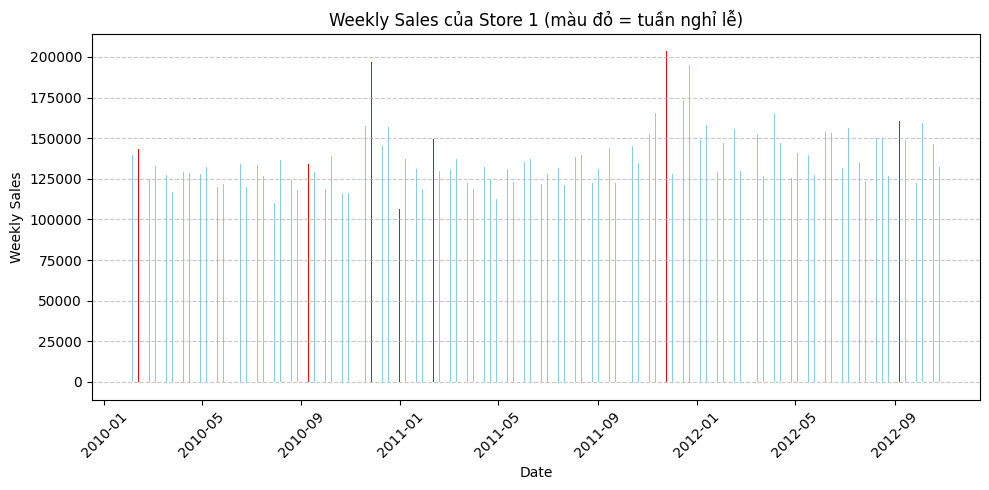

In [10]:
# WEEKY SALES CỦA STORE 1
# Chuyển cột Date sang kiểu datetime
df1['Date'] = pd.to_datetime(df1['Date'])

# Lọc dữ liệu cho Store 1
store1 = df1[df1['Store'] == 1]

colors = store1['IsHoliday'].map({True: 'red', False: 'skyblue'})

# Vẽ biểu đồ cột
plt.figure(figsize=(10,5))
plt.bar(store1['Date'], store1['Weekly_Sales'], color=colors)
plt.title('Weekly Sales của Store 1 (màu đỏ = tuần nghỉ lễ)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

          Date  Weekly_Sales  IsHoliday
0   2010-02-05  16836.121997      False
1   2010-02-12  16352.056032       True
2   2010-02-19  16216.658979      False
3   2010-02-26  14899.549688      False
4   2010-03-05  15921.015727      False
..         ...           ...        ...
138 2012-09-28  14765.327279      False
139 2012-10-05  15983.413747      False
140 2012-10-12  15427.596739      False
141 2012-10-19  15295.732397      False
142 2012-10-26  15391.725681      False

[143 rows x 3 columns]


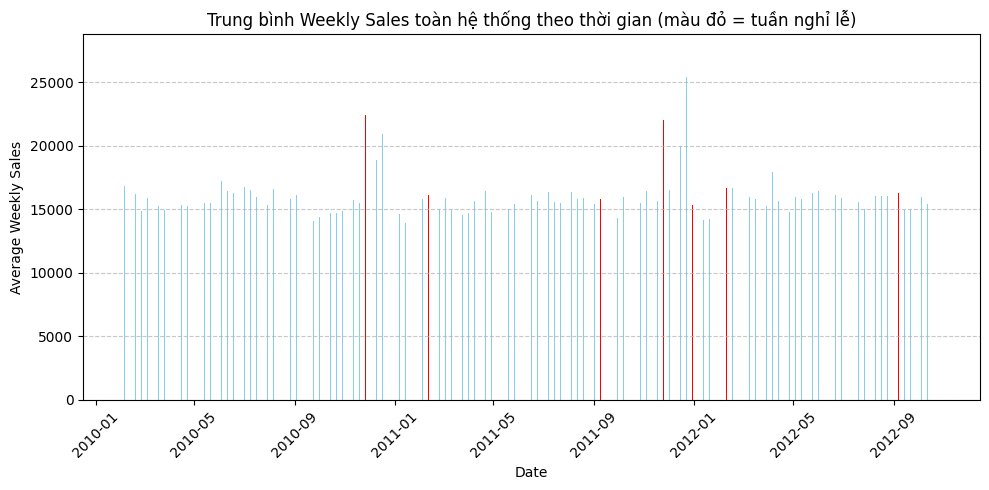

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Tính doanh thu trung bình hàng tuần toàn hệ thống
weekly_avg = df1.groupby('Date')['Weekly_Sales'].mean().reset_index()

# Lấy trạng thái IsHoliday cho mỗi ngày từ df1 (giả sử IsHoliday là nhất quán theo ngày)
holiday_status_per_date = df1.groupby('Date')['IsHoliday'].first().reset_index()

# Gộp trạng thái IsHoliday vào weekly_avg
weekly_avg = pd.merge(weekly_avg, holiday_status_per_date, on='Date', how='left')
print(weekly_avg)

colors = weekly_avg['IsHoliday'].map({True: 'red', False: 'skyblue'})

plt.figure(figsize=(10,5))
plt.bar(weekly_avg['Date'], weekly_avg['Weekly_Sales'], color=colors)
plt.title('Trung bình Weekly Sales toàn hệ thống theo thời gian (màu đỏ = tuần nghỉ lễ)')
plt.xlabel('Date')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

III. PROOF OF CONCEPT (Prophet)

Load dữ liệu đã được làm sạch + chuẩn hóa + merge dữ liệu

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
from prophet import Prophet

# Load data
train = pd.read_csv("cleaned_train.csv")
features = pd.read_csv("cleaned_features.csv")

# Convert Date
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Merge
merged = pd.merge(train, features, on=['Store', 'Date', 'IsHoliday'], how='left')
merged = merged.dropna()

C:\Users\aokik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Tạo các hàm

In [29]:
# Hàm tạo lag features
# Lag features là giá trị doanh thu của tuần trước đó, giúp mô hình dự báo theo chuỗi thời gian.
# Ví dụ lag_1 = doanh thu tuần trước, lag_52 = doanh thu cùng tuần năm trước.
def create_lags(df, lags=[1,2,4,52]):
    df = df.sort_values(['Store','Dept','Date'])
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(lag)
    df = df.dropna()
    return df

# Hàm prepare features
# X: tất cả biến dự báo, y: target (Weekly_Sales).
# Chuyển biến phân loại (Store, Dept) thành one-hot encoding.
# reference_columns giúp duy trì cùng cấu trúc cột khi dự báo tương lai.
def prepare_features(df, drop_cols=['Weekly_Sales', 'Date'], reference_columns=None):
    features = [c for c in df.columns if c not in drop_cols]
    cat_cols = [c for c in ['Store', 'Dept'] if c in df.columns]
    df_features = df[features]
    df_features = pd.get_dummies(df_features, columns=cat_cols, drop_first=True)

    if reference_columns is not None:
        for c in reference_columns:
            if c not in df_features.columns:
                df_features[c] = 0
        df_features = df_features[reference_columns]

    X = df_features
    y = df['Weekly_Sales'] if 'Weekly_Sales' in df.columns else None
    return X, y

# Hàm train RandomForest
# Sampling 50% dữ liệu để train nhanh hơn
# TimeSeriesSplit: cross-validation theo chuỗi thời gian (không random)
# In ra RMSE và MAE trên các fold
# Train lại mô hình trên toàn bộ sample cuối cùng để lưu model
def train_random_forest(X, y, sample_frac=0.5, n_estimators=50):
    X_sample = X.sample(frac=sample_frac, random_state=42)
    y_sample = y.loc[X_sample.index]

    tscv = TimeSeriesSplit(n_splits=2)
    rmses = []
    maes = []

    for train_index, test_index in tscv.split(X_sample):
        X_train, X_test = X_sample.iloc[train_index], X_sample.iloc[test_index]
        y_train, y_test = y_sample.iloc[train_index], y_sample.iloc[test_index]

        rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=10, max_features='sqrt', n_jobs=-1, random_state=42)
        rf.fit(X_train, y_train)
        preds = rf.predict(X_test)

        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        maes.append(mean_absolute_error(y_test, preds))

    print("CV RMSEs:", rmses)
    print("CV MAEs:", maes)

    rf_final = RandomForestRegressor(n_estimators=n_estimators, max_depth=10, max_features='sqrt', n_jobs=-1, random_state=42)
    rf_final.fit(X_sample, y_sample)
    return rf_final


In [30]:
# Tạo lag features
merged_lag = create_lags(merged)

# Prepare features
X, y = prepare_features(merged_lag)

# Train RandomForest với sample_frac=0.5 để nhanh hơn
rf_final = train_random_forest(X, y, sample_frac=0.5, n_estimators=50)

# Lưu model ra rf_model.pkl
feature_columns = X.columns.tolist()
joblib.dump(rf_final, "rf_model.pkl")
print("Saved model: rf_model.pkl")

CV RMSEs: [np.float64(2566.664656433961), np.float64(2619.8933035040586)]
CV MAEs: [1739.2688999755217, 1761.7412861797886]
Saved model: rf_model.pkl


Ước lượng giá trị ngoại sinh bằng Prophet

In [2]:
# Chọn thời gian dự báo: 8 tuần tiếp theo sau tuần cuối cùng trong dữ liệu
last_date = features['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=8, freq='W-FRI')  # đồng bộ ngày

future_features = pd.DataFrame({'Date': future_dates})
future_features['IsHoliday'] = 0

from prophet import Prophet

# Chuẩn bị dữ liệu Fuel_Price
fuel = features[['Date', 'Fuel_Price']].rename(columns={'Date': 'ds', 'Fuel_Price': 'y'})
m = Prophet()
m.fit(fuel)

future_fuel = m.make_future_dataframe(periods=8, freq='W-FRI')
forecast_fuel = m.predict(future_fuel)

# Merge kết quả dự báo vào future_features
future_features = future_features.merge(
    forecast_fuel[['ds', 'yhat']],
    left_on='Date', right_on='ds', how='left'
)
future_features.rename(columns={'yhat': 'Fuel_Price'}, inplace=True)
future_features.drop(columns=['ds'], inplace=True)

# Điền các giá trị trung bình cho biến khác
future_features['Temperature'] = features['Temperature'].mean()
future_features['CPI'] = features['CPI'].mean()
future_features['Unemployment'] = features['Unemployment'].mean()

for i in range(1, 6):
    future_features[f"MarkDown{i}"] = 0

future_features["Week"] = future_features["Date"].dt.isocalendar().week
future_features["Month"] = future_features["Date"].dt.month
future_features["Year"] = future_features["Date"].dt.year

future_features

02:58:33 - cmdstanpy - INFO - Chain [1] start processing
02:58:37 - cmdstanpy - INFO - Chain [1] done processing


,Date,IsHoliday,Fuel_Price,Temperature,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Week,Month,Year
0,2013-08-02,0,3.658690,59.389383,172.460809,2.150745,0,0,0,0,0,31,8,2013
1,2013-08-09,0,3.658148,59.389383,172.460809,2.150745,0,0,0,0,0,32,8,2013
2,2013-08-16,0,3.641544,59.389383,172.460809,2.150745,0,0,0,0,0,33,8,2013
3,2013-08-23,0,3.633018,59.389383,172.460809,2.150745,0,0,0,0,0,34,8,2013
4,2013-08-30,0,3.645443,59.389383,172.460809,2.150745,0,0,0,0,0,35,8,2013
5,2013-09-06,0,3.666701,59.389383,172.460809,2.150745,0,0,0,0,0,36,9,2013
6,2013-09-13,0,3.673247,59.389383,172.460809,2.150745,0,0,0,0,0,37,9,2013
7,2013-09-20,0,3.655669,59.389383,172.460809,2.150745,0,0,0,0,0,38,9,2013


Dự đoán weekly sales bằng mô hình đã train

In [32]:
# Dự báo Weekly_Sales dùng Random Forest
future_full = []

stores_depts = merged.groupby(['Store','Dept']).size().index.tolist()

# Khởi tạo lag_dict
lag_dict = {}
for s,d in stores_depts:
    past = merged[(merged['Store']==s)&(merged['Dept']==d)].sort_values('Date')
    lag_dict[(s,d)] = {
        'lag_1': past['Weekly_Sales'].iloc[-1] if len(past)>=1 else past['Weekly_Sales'].mean(),
        'lag_2': past['Weekly_Sales'].iloc[-2] if len(past)>=2 else past['Weekly_Sales'].mean(),
        'lag_4': past['Weekly_Sales'].iloc[-4] if len(past)>=4 else past['Weekly_Sales'].mean(),
        'lag_52': past['Weekly_Sales'].iloc[-52] if len(past)>=52 else past['Weekly_Sales'].mean(),
    }

# Forecast tuần theo tuần
for week_idx in range(8):
    current_week = last_date + pd.Timedelta(days=7*(week_idx+1))

    # Lấy Fuel_Price từ future_features
    fuel_price_row = future_features.loc[future_features['Date'] == current_week]
    fuel_price = fuel_price_row['Fuel_Price'].values[0] if not fuel_price_row.empty else features['Fuel_Price'].mean()

    week_rows = []
    for s,d in stores_depts:
        row = {
            'Store': s,
            'Dept': d,
            'Date': current_week,
            'IsHoliday': 0,
            'Fuel_Price': fuel_price,
            'Temperature': future_features['Temperature'].mean(),
            'CPI': future_features['CPI'].mean(),
            'Unemployment': future_features['Unemployment'].mean(),
        }

        for i in range(1,6):
            row[f'MarkDown{i}'] = 0

        row['Week'] = current_week.isocalendar().week
        row['Month'] = current_week.month
        row['Year'] = current_week.year

        # Thêm lag features
        row['lag_1'] = lag_dict[(s,d)]['lag_1']
        row['lag_2'] = lag_dict[(s,d)]['lag_2']
        row['lag_4'] = lag_dict[(s,d)]['lag_4']
        row['lag_52'] = lag_dict[(s,d)]['lag_52']

        week_rows.append(row)

    week_df = pd.DataFrame(week_rows)
    X_week, _ = prepare_features(week_df, reference_columns=feature_columns)
    y_pred = rf_final.predict(X_week)
    week_df['Weekly_Sales_Pred'] = y_pred

    # Cập nhật lag_dict
    for idx, (s,d) in enumerate(stores_depts):
        lag_dict[(s,d)]['lag_2'] = lag_dict[(s,d)]['lag_1']
        lag_dict[(s,d)]['lag_1'] = y_pred[idx]

    future_full.append(week_df)
    
future_full = pd.concat(future_full, ignore_index=True)

future_full.head(16)

,Store,Dept,Date,IsHoliday,Fuel_Price,Temperature,CPI,Unemployment,MarkDown1,MarkDown2,...,MarkDown4,MarkDown5,Week,Month,Year,lag_1,lag_2,lag_4,lag_52,Weekly_Sales_Pred
0,1,1,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,27390.81,24185.27,21904.47,39886.06,30810.433479
1,1,2,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,43134.88,42354.72,47494.61,47313.62,43169.973851
2,1,3,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,9350.90,8548.87,11676.98,9189.20,9926.702050
3,1,4,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,36292.60,35549.19,39311.93,39354.84,36896.647360
4,1,5,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,25846.94,20413.83,25508.81,31956.07,25955.742160
5,1,6,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,4032.50,3496.69,3843.29,6227.43,4563.979303
6,1,7,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,21449.85,21937.45,22071.39,24182.96,21753.095718
7,1,8,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,39255.35,38668.75,42663.75,36959.48,40713.443399
8,1,9,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,41040.84,36690.81,40439.53,47494.61,40888.179347
9,1,10,2013-08-02,0,3.65869,59.389383,172.460809,2.150745,0,0,...,0,0,31,8,2013,26285.27,29442.38,27822.40,31588.66,29921.106103
